# Spectroscopic vs Photometric T_eff Comparison

Comparing three Teff estimates from Gaia DR3:
- `teff_gaia_corrected`: **GSP-Phot** photometric Teff — fits a single-star SED to the blended EB light
- `teff_msc1`: **MSC primary** component Teff — decomposes the binary using BP/RP + parallax
- `teff_msc2`: **MSC secondary** component Teff — same decomposition, fainter/cooler component

**Physical expectation:** For a flux-dominated primary, T_MSC1 ≥ T_GSP-Phot ≥ T_MSC2. GSP-Phot bias toward primary should vanish when components are equal-mass (ratio → 1).

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)  # ensure save_figure writes to reports/figures/ at project root

import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.config import get_config
from src.visualization.validation_plots import save_figure

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

MISSING = -999.0
T_MIN, T_MAX = 2500, 40000

In [2]:
config = get_config()
catalog_path = config.get_dataset_path('eb_catalog_teff', 'processed')
df = pl.read_parquet(catalog_path)
print(f"Catalog shape: {df.shape}")

# Filter to rows where all three values are valid and physically plausible
df_valid = df.filter(
    (pl.col('teff_gaia_corrected').is_not_null()) &
    (pl.col('teff_gaia_corrected') != MISSING) &
    (pl.col('teff_gaia_corrected').is_between(T_MIN, T_MAX)) &
    (pl.col('teff_msc1').is_not_null()) &
    (pl.col('teff_msc1') != MISSING) &
    (pl.col('teff_msc1').is_between(T_MIN, T_MAX)) &
    (pl.col('teff_msc2').is_not_null()) &
    (pl.col('teff_msc2') != MISSING) &
    (pl.col('teff_msc2').is_between(T_MIN, T_MAX))
)
print(f"Objects with valid GSP-Phot + MSC1 + MSC2: {df_valid.height:,}  "
      f"({100*df_valid.height/df.height:.1f}% of catalog)")

t_phot = df_valid['teff_gaia_corrected'].to_numpy().astype(float)
t_msc1 = df_valid['teff_msc1'].to_numpy().astype(float)
t_msc2 = df_valid['teff_msc2'].to_numpy().astype(float)

for label, arr in [('GSP-Phot', t_phot), ('MSC primary', t_msc1), ('MSC secondary', t_msc2)]:
    print(f"{label:15s}: mean={arr.mean():.0f} K  std={arr.std():.0f} K  "
          f"[{arr.min():.0f}, {arr.max():.0f}] K")

Catalog shape: (2184477, 23)
Objects with valid GSP-Phot + MSC1 + MSC2: 909,441  (41.6% of catalog)
GSP-Phot       : mean=5894 K  std=2152 K  [3000, 39881] K
MSC primary    : mean=5146 K  std=872 K  [3005, 7997] K
MSC secondary  : mean=4511 K  std=935 K  [3003, 7998] K


In [3]:
def comparison_metrics(x, y, label_x, label_y):
    """Full suite of comparison metrics for two Teff arrays."""
    diff = x - y
    pearson_r, _ = stats.pearsonr(x, y)
    spearman_r, _ = stats.spearmanr(x, y)

    # Lin's concordance correlation coefficient (CCC) — stricter than Pearson: penalises location/scale shifts
    mx, my = np.mean(x), np.mean(y)
    cov_xy = np.mean((x - mx) * (y - my))
    ccc = 2 * cov_xy / (np.var(x) + np.var(y) + (mx - my) ** 2)

    bias    = np.mean(diff)
    scatter = np.std(diff)
    mae     = np.mean(np.abs(diff))
    rmse    = np.sqrt(np.mean(diff ** 2))
    p16, p50, p84 = np.percentile(diff, [16, 50, 84])
    mad     = np.median(np.abs(diff - np.median(diff)))

    ks_stat, ks_p  = stats.ks_2samp(x, y)
    w_dist         = stats.wasserstein_distance(x, y)

    return {
        'pair':           f'{label_x} vs {label_y}',
        'n':              len(x),
        'Pearson r':      pearson_r,
        'Spearman ρ':     spearman_r,
        'CCC':            ccc,
        'Bias (x−y)':     bias,
        'Scatter σ':      scatter,
        'MAE':            mae,
        'RMSE':           rmse,
        'p16 diff':       p16,
        'Median diff':    p50,
        'p84 diff':       p84,
        'MAD diff':       mad,
        'KS stat':        ks_stat,
        'KS p-value':     ks_p,
        'Wasserstein (K)': w_dist,
    }

m1 = comparison_metrics(t_phot, t_msc1, 'GSP-Phot', 'MSC primary')
m2 = comparison_metrics(t_phot, t_msc2, 'GSP-Phot', 'MSC secondary')
m3 = comparison_metrics(t_msc1, t_msc2, 'MSC primary', 'MSC secondary')

metrics_df = pd.DataFrame([m1, m2, m3]).set_index('pair')
print("=== COMPARISON METRICS ===\n")
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.max_columns', 20, 'display.width', 120):
    print(metrics_df[['n','Pearson r','Spearman ρ','CCC','Bias (x−y)','Scatter σ',
                       'MAE','RMSE','Median diff','MAD diff','KS stat','KS p-value','Wasserstein (K)']].T)

=== COMPARISON METRICS ===

pair             GSP-Phot vs MSC primary  GSP-Phot vs MSC secondary  MSC primary vs MSC secondary
n                            909441.0000                909441.0000                   909441.0000
Pearson r                         0.4357                     0.4280                        0.8571
Spearman ρ                        0.5291                     0.5163                        0.8991
CCC                               0.2748                     0.2322                        0.6858
Bias (x−y)                      748.1717                  1383.0684                      634.8967
Scatter σ                      1937.8560                  1944.7417                      486.8353
MAE                             989.9108                  1415.1996                      705.1100
RMSE                           2077.2691                  2386.3987                      800.0640
Median diff                     192.3350                   879.7534                      7

---\n## Catalog coverage: GSP-Phot vs MSC overlap

Both (GSP-Phot + MSC)    :    909,457  (41.6%)
GSP-Phot only            :    366,709  (16.8%)
MSC only                 :    164,635  (7.5%)
Neither                  :    743,676  (34.0%)


   Saved: reports/figures/spectroscopic_comparison/gspphot_msc_coverage_overlap.png


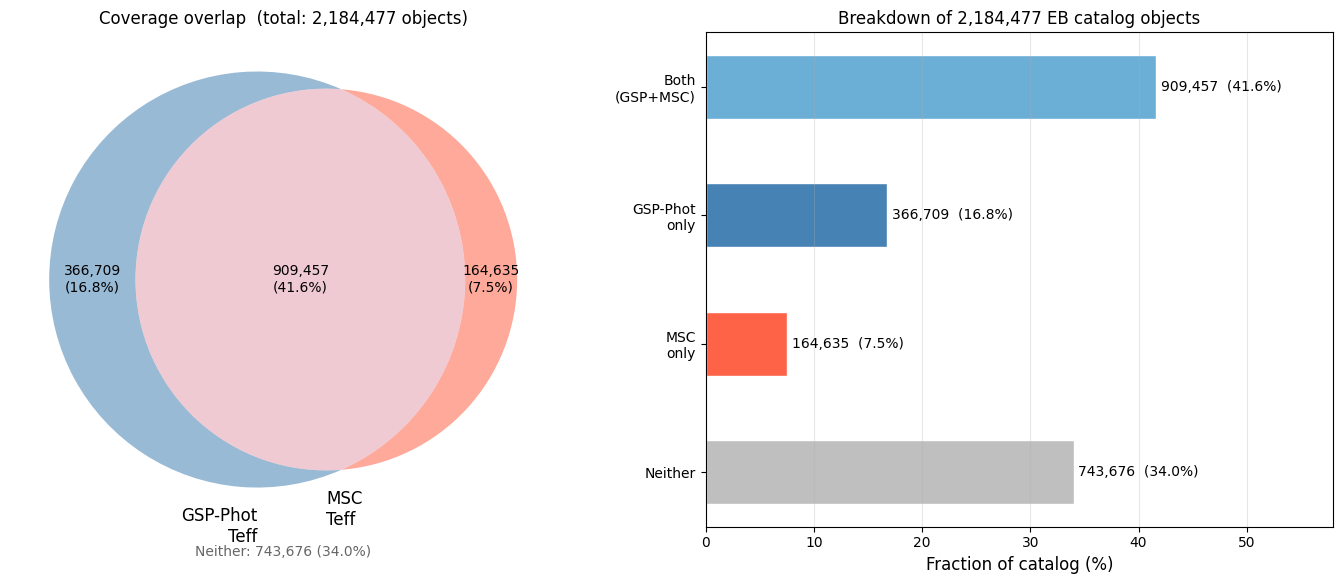

In [4]:
from matplotlib_venn import venn2

df_full = pl.read_parquet(config.get_dataset_path('eb_catalog_teff', 'processed'))
N = df_full.height

def has(col):
    return pl.col(col).is_not_null() & (pl.col(col) != MISSING)

n_gsp      = df_full.filter(has('teff_gaia_corrected')).height
n_msc      = df_full.filter(has('teff_msc1')).height
n_both     = df_full.filter(has('teff_gaia_corrected') & has('teff_msc1')).height
n_gsp_only = n_gsp - n_both
n_msc_only = n_msc - n_both
n_neither  = N - n_gsp - n_msc_only

for label, n in [('Both (GSP-Phot + MSC)', n_both), ('GSP-Phot only', n_gsp_only),
                 ('MSC only', n_msc_only), ('Neither', n_neither)]:
    print(f'{label:25s}: {n:>10,}  ({100*n/N:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Venn diagram
ax = axes[0]
ax.set_aspect('equal')
v = venn2(
    subsets=(n_gsp_only, n_msc_only, n_both),
    set_labels=('GSP-Phot\nTeff', 'MSC\nTeff'),
    set_colors=('steelblue', 'tomato'),
    alpha=0.55,
    ax=ax,
)
for subset_id, n in [('10', n_gsp_only), ('01', n_msc_only), ('11', n_both)]:
    lbl = v.get_label_by_id(subset_id)
    if lbl:
        lbl.set_text(f'{n:,}\n({100*n/N:.1f}%)')
        lbl.set_fontsize(10)
for lbl in v.set_labels:
    lbl.set_fontsize(12)
ax.set_title(f'Coverage overlap  (total: {N:,} objects)', fontsize=12)
ax.text(0.5, -0.06, f'Neither: {n_neither:,} ({100*n_neither/N:.1f}%)',
        transform=ax.transAxes, ha='center', fontsize=10, color='0.4')

# Horizontal bar breakdown
ax = axes[1]
labels  = ['Both\n(GSP+MSC)', 'GSP-Phot\nonly', 'MSC\nonly', 'Neither']
values  = [n_both, n_gsp_only, n_msc_only, n_neither]
palette = ['#6baed6', 'steelblue', 'tomato', '0.75']
bars = ax.barh(labels, [v / N * 100 for v in values],
               color=palette, edgecolor='white', height=0.5)
for bar, n, pct in zip(bars, values, [v / N * 100 for v in values]):
    ax.text(pct + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{n:,}  ({pct:.1f}%)', va='center', fontsize=10)
ax.set_xlabel('Fraction of catalog (%)')
ax.set_xlim(0, 58)
ax.set_title(f'Breakdown of {N:,} EB catalog objects', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

plt.tight_layout()
save_figure(fig, 'gspphot_msc_coverage_overlap.png', 'spectroscopic_comparison')
plt.show()

## Figure 1 — T_eff distributions and CDFs

   Saved: reports/figures/spectroscopic_comparison/gspphot_msc_teff_distributions.png


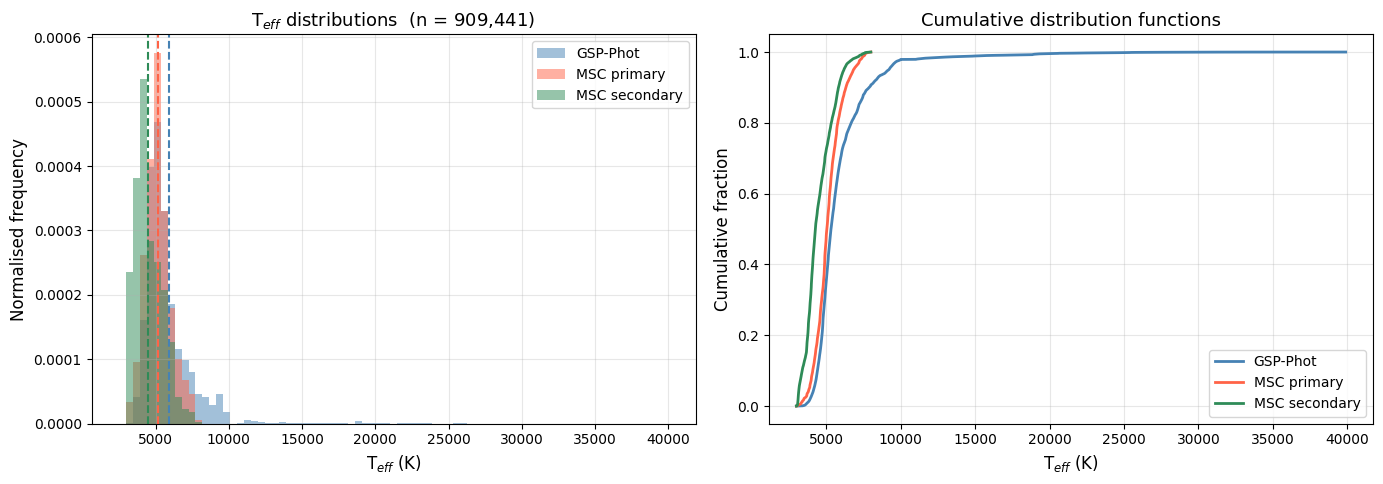

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.linspace(T_MIN, T_MAX, 80)
colors = {'GSP-Phot': 'steelblue', 'MSC primary': 'tomato', 'MSC secondary': 'seagreen'}

# Histogram overlay
ax = axes[0]
for arr, label in zip([t_phot, t_msc1, t_msc2], colors):
    ax.hist(arr, bins=bins, alpha=0.5, density=True, label=label,
            color=colors[label], edgecolor='none')
    ax.axvline(np.mean(arr), color=colors[label], linestyle='--', lw=1.5)
ax.set_xlabel('T$_{eff}$ (K)')
ax.set_ylabel('Normalised frequency')
ax.set_title(f'T$_{{eff}}$ distributions  (n = {len(t_phot):,})')
ax.legend()
ax.grid(True, alpha=0.3)

# CDF overlay
ax = axes[1]
for arr, label in zip([t_phot, t_msc1, t_msc2], colors):
    s = np.sort(arr)
    ax.plot(s, np.linspace(0, 1, len(s)), color=colors[label], lw=2, label=label)
ax.set_xlabel('T$_{eff}$ (K)')
ax.set_ylabel('Cumulative fraction')
ax.set_title('Cumulative distribution functions')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'gspphot_msc_teff_distributions.png', 'spectroscopic_comparison')
plt.show()

## Figure 2 — Scatter plots (hexbin, log density)

   Saved: reports/figures/spectroscopic_comparison/gspphot_msc_teff_scatter.png


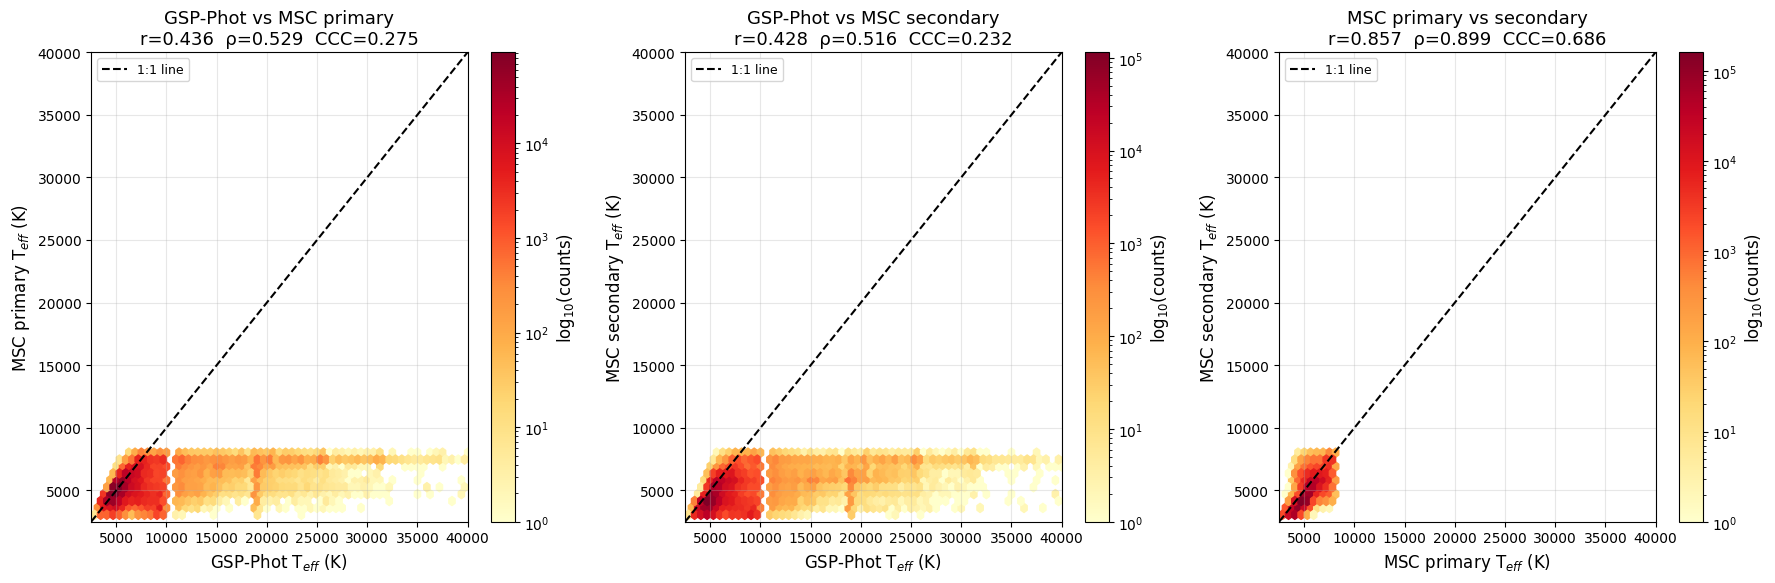

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
pairs = [
    (t_phot, t_msc1,  'GSP-Phot T$_{eff}$ (K)',    'MSC primary T$_{eff}$ (K)',    'GSP-Phot vs MSC primary',   m1),
    (t_phot, t_msc2,  'GSP-Phot T$_{eff}$ (K)',    'MSC secondary T$_{eff}$ (K)',  'GSP-Phot vs MSC secondary', m2),
    (t_msc1, t_msc2,  'MSC primary T$_{eff}$ (K)', 'MSC secondary T$_{eff}$ (K)', 'MSC primary vs secondary',   m3),
]

for ax, (x, y, xlabel, ylabel, title, m) in zip(axes, pairs):
    hb = ax.hexbin(x, y, gridsize=60, cmap='YlOrRd', mincnt=1, bins='log',
                   extent=[T_MIN, T_MAX, T_MIN, T_MAX])
    ax.plot([T_MIN, T_MAX], [T_MIN, T_MAX], 'k--', lw=1.5, label='1:1 line')
    ax.set_xlim(T_MIN, T_MAX)
    ax.set_ylim(T_MIN, T_MAX)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title}\n"
                 f"r={m['Pearson r']:.3f}  ρ={m['Spearman ρ']:.3f}  CCC={m['CCC']:.3f}")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.colorbar(hb, ax=ax, label='log$_{10}$(counts)')

plt.tight_layout()
save_figure(fig, 'gspphot_msc_teff_scatter.png', 'spectroscopic_comparison')
plt.show()

## Figure 3 — Bland–Altman agreement plots\n\nDifference vs mean of each pair. Dashed line = mean bias; dotted lines = ±1.96σ limits of agreement (LoA).

   Saved: reports/figures/spectroscopic_comparison/gspphot_msc_bland_altman.png


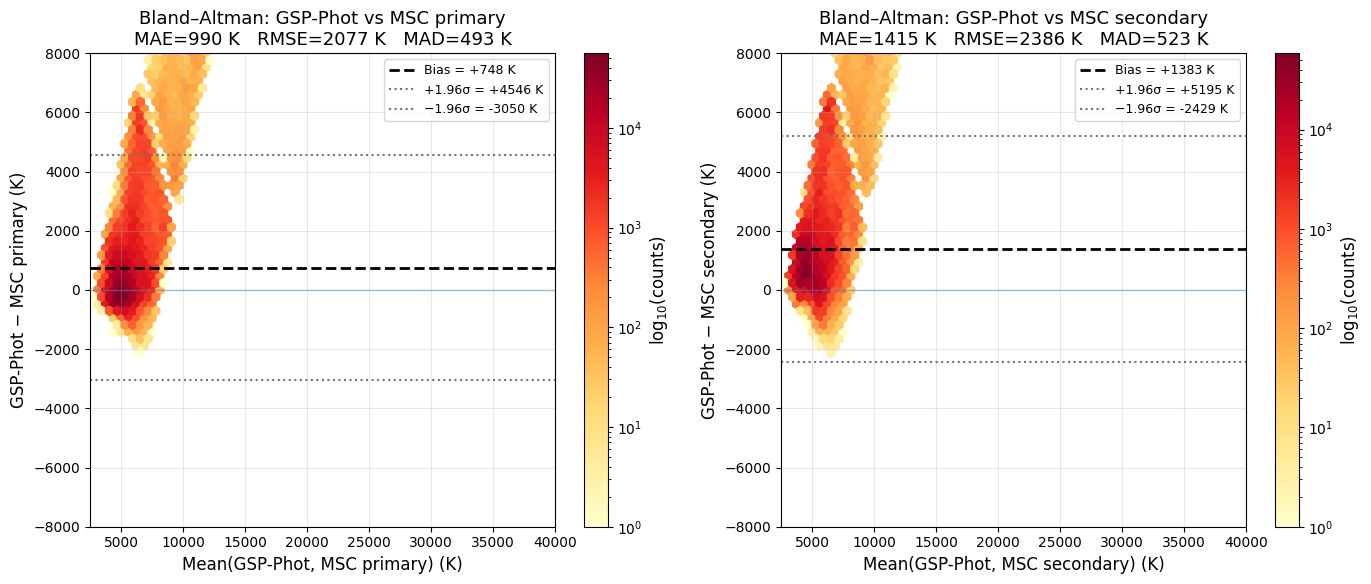

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ba_pairs = [
    (t_phot, t_msc1, 'GSP-Phot', 'MSC primary',   m1),
    (t_phot, t_msc2, 'GSP-Phot', 'MSC secondary', m2),
]
D_LIM = 8000

for ax, (x, y, lx, ly, m) in zip(axes, ba_pairs):
    mean_xy = (x + y) / 2
    diff_xy = x - y
    bias = m['Bias (x−y)']
    loa  = 1.96 * m['Scatter σ']

    hb = ax.hexbin(mean_xy, diff_xy, gridsize=60, cmap='YlOrRd', mincnt=1, bins='log',
                   extent=[T_MIN, T_MAX, -D_LIM, D_LIM])
    ax.axhline(0,           color='tab:blue', lw=1,   linestyle='-',  alpha=0.4)
    ax.axhline(bias,        color='k',         lw=2,   linestyle='--', label=f'Bias = {bias:+.0f} K')
    ax.axhline(bias + loa,  color='0.45',      lw=1.5, linestyle=':',  label=f'+1.96σ = {bias+loa:+.0f} K')
    ax.axhline(bias - loa,  color='0.45',      lw=1.5, linestyle=':',  label=f'−1.96σ = {bias-loa:+.0f} K')

    ax.set_xlim(T_MIN, T_MAX)
    ax.set_ylim(-D_LIM, D_LIM)
    ax.set_xlabel(f'Mean({lx}, {ly}) (K)')
    ax.set_ylabel(f'{lx} − {ly} (K)')
    ax.set_title(f'Bland–Altman: {lx} vs {ly}\n'
                 f'MAE={m["MAE"]:.0f} K   RMSE={m["RMSE"]:.0f} K   MAD={m["MAD diff"]:.0f} K')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.colorbar(hb, ax=ax, label='log$_{10}$(counts)')

plt.tight_layout()
save_figure(fig, 'gspphot_msc_bland_altman.png', 'spectroscopic_comparison')
plt.show()

## Figure 4 — Residual distributions\n\nHistogram of (X − Y) with a fitted Gaussian overlay. Departure from Gaussian indicates outlier populations or non-linear bias.

   Saved: reports/figures/spectroscopic_comparison/gspphot_msc_residuals.png


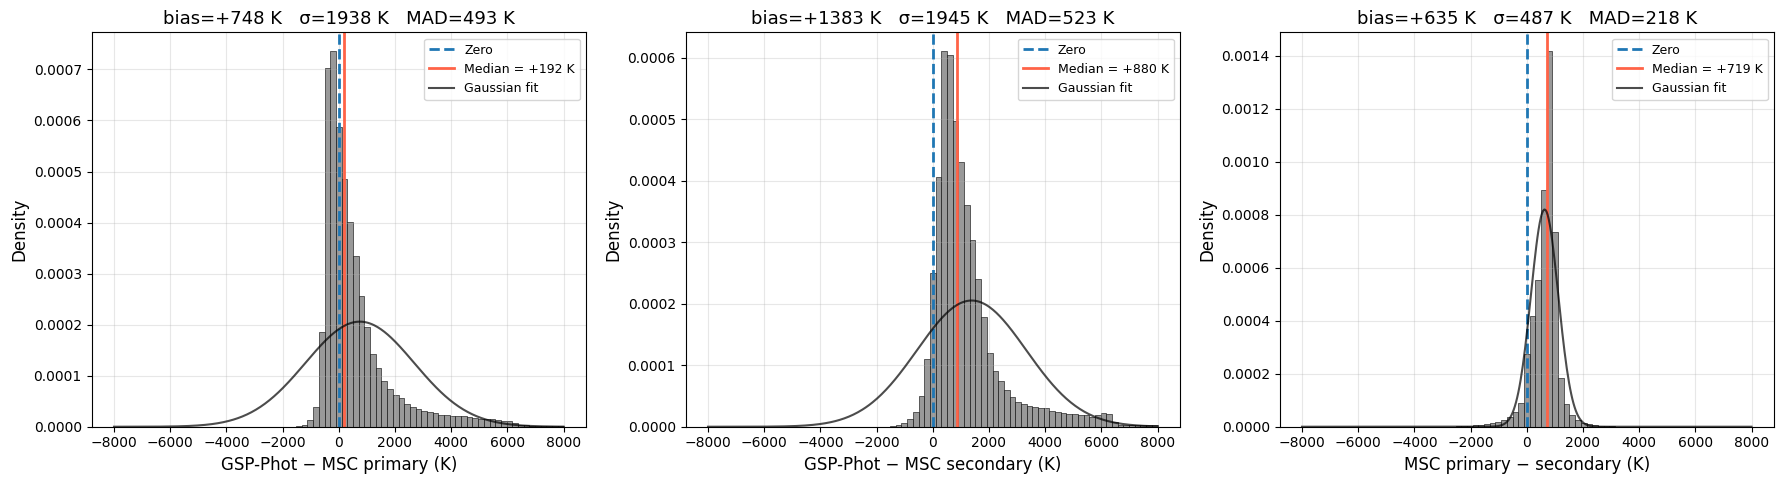

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
diff_triples = [
    (t_phot - t_msc1, 'GSP-Phot − MSC primary (K)',   m1),
    (t_phot - t_msc2, 'GSP-Phot − MSC secondary (K)', m2),
    (t_msc1 - t_msc2, 'MSC primary − secondary (K)',   m3),
]
bins_d = np.linspace(-8000, 8000, 80)

for ax, (diff, xlabel, m) in zip(axes, diff_triples):
    ax.hist(diff, bins=bins_d, color='0.6', edgecolor='black', linewidth=0.4, density=True)
    ax.axvline(0,                    color='tab:blue', lw=2,   linestyle='--', label='Zero')
    ax.axvline(m['Median diff'],     color='tomato',   lw=2,   linestyle='-',
               label=f'Median = {m["Median diff"]:+.0f} K')

    # Gaussian overlay using bias and scatter
    xg = np.linspace(-8000, 8000, 400)
    ax.plot(xg, stats.norm.pdf(xg, m['Bias (x−y)'], m['Scatter σ']),
            'k-', lw=1.5, alpha=0.7, label='Gaussian fit')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_title(f'bias={m["Bias (x−y)"]:+.0f} K   '
                 f'σ={m["Scatter σ"]:.0f} K   MAD={m["MAD diff"]:.0f} K')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'gspphot_msc_residuals.png', 'spectroscopic_comparison')
plt.show()

## Figure 5 — Physical interpretation: component temperature ratio\n\n`T_MSC1 / T_MSC2` quantifies how similar the two binary components are (1 = identical twins). We examine how this ratio relates to the GSP-Phot blended estimate and whether it drives the photometric bias.

   Saved: reports/figures/spectroscopic_comparison/gspphot_msc_physical_interpretation.png


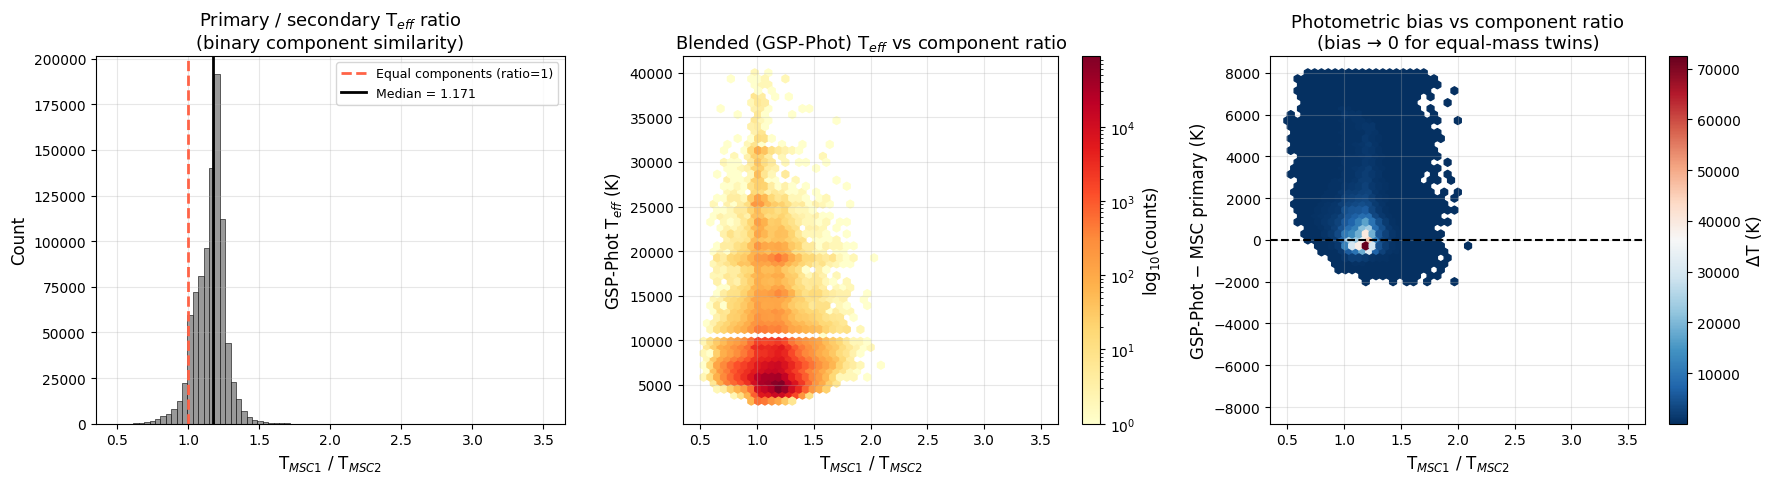

In [9]:
ratio = t_msc1 / t_msc2           # primary / secondary temperature ratio
diff_phot_msc1 = t_phot - t_msc1  # photometric bias relative to primary

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: distribution of temperature ratio
ax = axes[0]
bins_r = np.linspace(0.5, 3.5, 80)
ax.hist(ratio, bins=bins_r, color='0.6', edgecolor='black', linewidth=0.4)
ax.axvline(1.0,           color='tomato',   lw=2, linestyle='--', label='Equal components (ratio=1)')
ax.axvline(np.median(ratio), color='k',     lw=2, linestyle='-',
           label=f'Median = {np.median(ratio):.3f}')
ax.set_xlabel('T$_{MSC1}$ / T$_{MSC2}$')
ax.set_ylabel('Count')
ax.set_title('Primary / secondary T$_{eff}$ ratio\n(binary component similarity)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: GSP-Phot Teff vs ratio (does blended Teff scale with component ratio?)
ax = axes[1]
hb = ax.hexbin(ratio, t_phot, gridsize=50, cmap='YlOrRd', mincnt=1, bins='log',
               extent=[0.5, 3.5, T_MIN, T_MAX])
ax.set_xlabel('T$_{MSC1}$ / T$_{MSC2}$')
ax.set_ylabel('GSP-Phot T$_{eff}$ (K)')
ax.set_title('Blended (GSP-Phot) T$_{eff}$ vs component ratio')
ax.grid(True, alpha=0.3)
plt.colorbar(hb, ax=ax, label='log$_{10}$(counts)')

# Panel 3: GSP-Phot bias (vs primary) vs ratio — bias should vanish at ratio=1
ax = axes[2]
hb = ax.hexbin(ratio, diff_phot_msc1, gridsize=50, cmap='RdBu_r', mincnt=1,
               extent=[0.5, 3.5, -D_LIM, D_LIM])
ax.axhline(0, color='k', lw=1.5, linestyle='--')
ax.set_xlabel('T$_{MSC1}$ / T$_{MSC2}$')
ax.set_ylabel('GSP-Phot − MSC primary (K)')
ax.set_title('Photometric bias vs component ratio\n(bias → 0 for equal-mass twins)')
ax.grid(True, alpha=0.3)
plt.colorbar(hb, ax=ax, label='ΔT (K)')

plt.tight_layout()
save_figure(fig, 'gspphot_msc_physical_interpretation.png', 'spectroscopic_comparison')
plt.show()

---\n## Part 2 — Comparison with catalogued temperatures\n\nTwo external catalogs with spectroscopically measured component temperatures, cross-matched with Gaia DR3:\n- **DEBCat** — detached eclipsing binaries; temperatures stored as `logT1`, `logT2` (log₁₀ K)\n- **WUMaCat** — W UMa contact binaries; temperatures stored as `T1`, `T2` (K)\n\nFor each catalog, three comparisons:\n1. **GSP-Phot** (`teff_gaia_corrected`) vs catalogue T1\n2. **MSC primary** (`teff_msc1`) vs catalogue T1\n3. **MSC secondary** (`teff_msc2`) vs catalogue T2

In [10]:
from astropy.table import Table

# --- Load unified catalog columns needed for comparison ---
cat = pl.read_parquet(
    config.get_dataset_path('eb_catalog_teff', 'processed')
).select(['source_id', 'teff_gaia_corrected', 'teff_msc1', 'teff_msc2'])

# --- DEBCat ---
deb_raw = Table.read(
    config.get_dataset_path('debcat_gaia', 'raw'), format='ascii.ecsv'
).to_pandas()
deb_raw = deb_raw.rename(columns={'SOURCE_ID': 'source_id'})
deb_raw['T1_cat'] = 10 ** deb_raw['logT1'].astype(float)
deb_raw['T2_cat'] = 10 ** deb_raw['logT2'].astype(float)
deb_raw.loc[deb_raw['T2_cat'] < 100, 'T2_cat'] = float('nan')   # sentinel -9.990
deb_raw.loc[deb_raw['T1_cat'] < 100, 'T1_cat'] = float('nan')

deb = cat.join(
    pl.from_pandas(deb_raw[['source_id', 'T1_cat', 'T2_cat']]),
    on='source_id', how='inner'
).filter(
    pl.col('teff_gaia_corrected').is_not_null() &
    (pl.col('teff_gaia_corrected') != MISSING)
)
print(f"DEBCat matched: {deb.height} objects")

# --- WUMaCat ---
wuma_raw = Table.read(
    config.get_dataset_path('wumacat_gaia', 'raw'), format='ascii.ecsv'
).to_pandas()
wuma_raw = wuma_raw.rename(columns={'SOURCE_ID': 'source_id'})
wuma_raw['T1_cat'] = wuma_raw['T1'].astype(float)
wuma_raw['T2_cat'] = wuma_raw['T2'].astype(float)

wuma = cat.join(
    pl.from_pandas(wuma_raw[['source_id', 'T1_cat', 'T2_cat']]),
    on='source_id', how='inner'
).filter(
    pl.col('teff_gaia_corrected').is_not_null() &
    (pl.col('teff_gaia_corrected') != MISSING)
)
print(f"WUMaCat matched: {wuma.height} objects")

# Print valid-pair counts per comparison
for name, df in [('DEBCat', deb), ('WUMaCat', wuma)]:
    n_gsp  = df.filter(pl.col('T1_cat').is_not_null()).height
    n_msc1 = df.filter(pl.col('teff_msc1').is_not_null() & (pl.col('teff_msc1') != MISSING) & pl.col('T1_cat').is_not_null()).height
    n_msc2 = df.filter(pl.col('teff_msc2').is_not_null() & (pl.col('teff_msc2') != MISSING) & pl.col('T2_cat').is_not_null()).height
    print(f"{name}: GSP-Phot vs T1={n_gsp}, MSC1 vs T1={n_msc1}, MSC2 vs T2={n_msc2}")

DEBCat matched: 120 objects
WUMaCat matched: 416 objects
DEBCat: GSP-Phot vs T1=120, MSC1 vs T1=120, MSC2 vs T2=119
WUMaCat: GSP-Phot vs T1=416, MSC1 vs T1=413, MSC2 vs T2=413


In [11]:
def scatter_kde_panel(ax, x, y, xlabel, ylabel, title, lims, n_levels=6, color='steelblue'):
    """
    Scatter plot with KDE density contours.
    Valid pairs only (both finite, within lims).
    Returns (n_valid, pearson_r, bias, scatter).
    """
    mask = np.isfinite(x) & np.isfinite(y) & (x >= lims[0]) & (x <= lims[1]) & (y >= lims[0]) & (y <= lims[1])
    xv, yv = x[mask], y[mask]
    n = len(xv)

    # Scatter
    ax.scatter(xv, yv, s=18, alpha=0.55, color=color, edgecolors='none', zorder=3)

    # KDE contours (need at least ~10 points)
    if n >= 10:
        try:
            from scipy.stats import gaussian_kde
            xy = np.vstack([xv, yv])
            kde = gaussian_kde(xy)
            grid_pts = 120
            xi = np.linspace(lims[0], lims[1], grid_pts)
            yi = np.linspace(lims[0], lims[1], grid_pts)
            Xi, Yi = np.meshgrid(xi, yi)
            Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
            levels = np.percentile(Zi[Zi > 0], np.linspace(20, 95, n_levels))
            levels = np.unique(levels)
            ax.contour(Xi, Yi, Zi, levels=levels, colors='k', linewidths=0.9, alpha=0.7, zorder=4)
        except Exception:
            pass

    # 1:1 line
    ax.plot(lims, lims, 'r--', lw=1.5, zorder=5, label='1:1')

    # Metrics
    if n >= 2:
        r, _ = stats.pearsonr(xv, yv)
        bias = np.mean(xv - yv)
        sigma = np.std(xv - yv)
        mae = np.mean(np.abs(xv - yv))
        stats_str = (f'n={n}\nr={r:.3f}\nbias={bias:+.0f} K\nσ={sigma:.0f} K\nMAE={mae:.0f} K')
        ax.text(0.03, 0.97, stats_str, transform=ax.transAxes, fontsize=9,
                va='top', ha='left', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.25)
    ax.set_aspect('equal')
    return n

### Figure 6 — DEBCat (detached EBs): GSP-Phot, MSC1, MSC2 vs catalogue T1/T2

   Saved: reports/figures/spectroscopic_comparison/debcat_teff_comparison.png


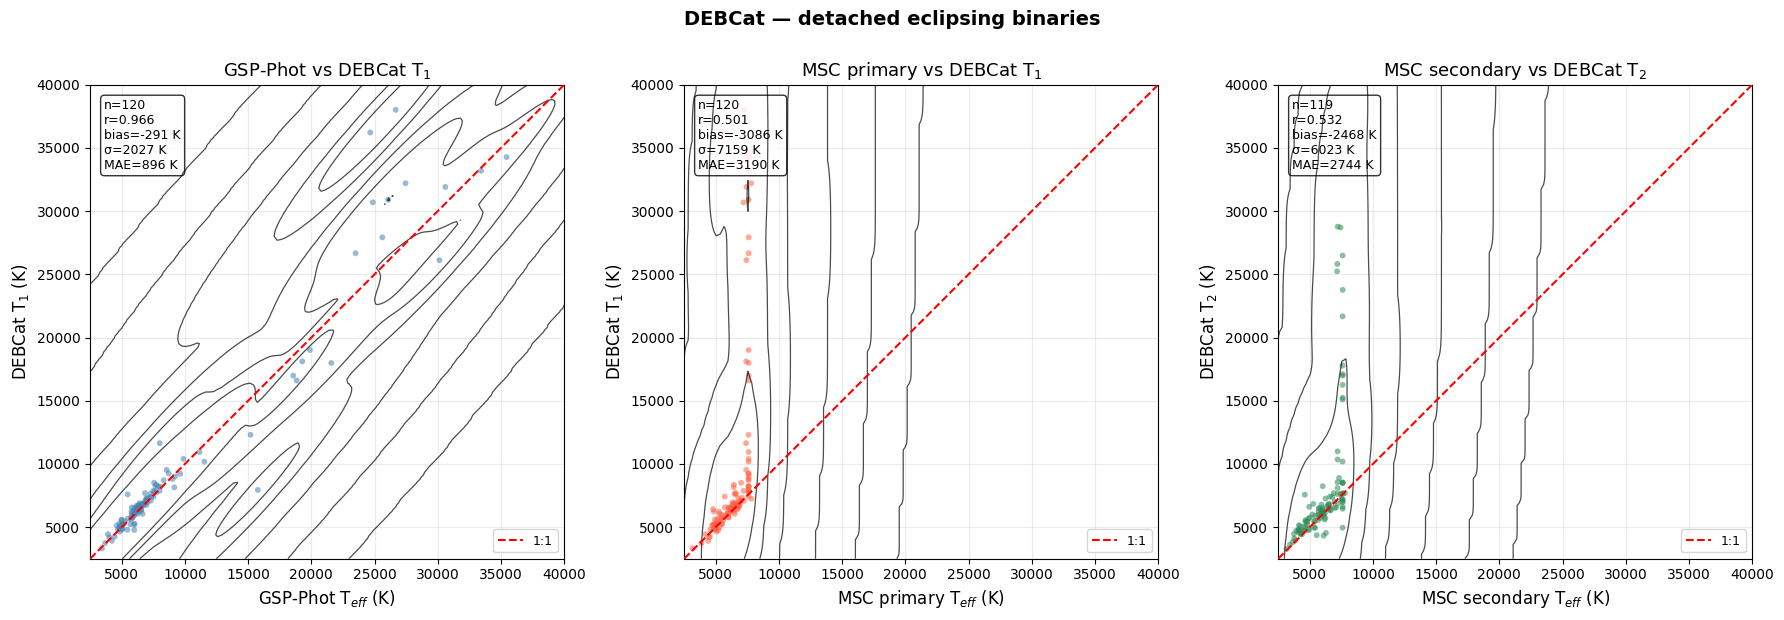

In [12]:
deb_np = deb.to_pandas()
LIMS_DEB = (2500, 40000)   # DEBCat includes hot stars

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('DEBCat — detached eclipsing binaries', fontsize=14, fontweight='bold', y=1.01)

scatter_kde_panel(
    axes[0],
    x=deb_np['teff_gaia_corrected'].values,
    y=deb_np['T1_cat'].values,
    xlabel='GSP-Phot T$_{eff}$ (K)',
    ylabel='DEBCat T$_1$ (K)',
    title='GSP-Phot vs DEBCat T$_1$',
    lims=LIMS_DEB, color='steelblue',
)
scatter_kde_panel(
    axes[1],
    x=deb_np['teff_msc1'].replace(-999.0, float('nan')).values,
    y=deb_np['T1_cat'].values,
    xlabel='MSC primary T$_{eff}$ (K)',
    ylabel='DEBCat T$_1$ (K)',
    title='MSC primary vs DEBCat T$_1$',
    lims=LIMS_DEB, color='tomato',
)
scatter_kde_panel(
    axes[2],
    x=deb_np['teff_msc2'].replace(-999.0, float('nan')).values,
    y=deb_np['T2_cat'].values,
    xlabel='MSC secondary T$_{eff}$ (K)',
    ylabel='DEBCat T$_2$ (K)',
    title='MSC secondary vs DEBCat T$_2$',
    lims=LIMS_DEB, color='seagreen',
)

plt.tight_layout()
save_figure(fig, 'debcat_teff_comparison.png', 'spectroscopic_comparison')
plt.show()

### Figure 7 — WUMaCat (contact EBs): GSP-Phot, MSC1, MSC2 vs catalogue T1/T2

   Saved: reports/figures/spectroscopic_comparison/wumacat_teff_comparison.png


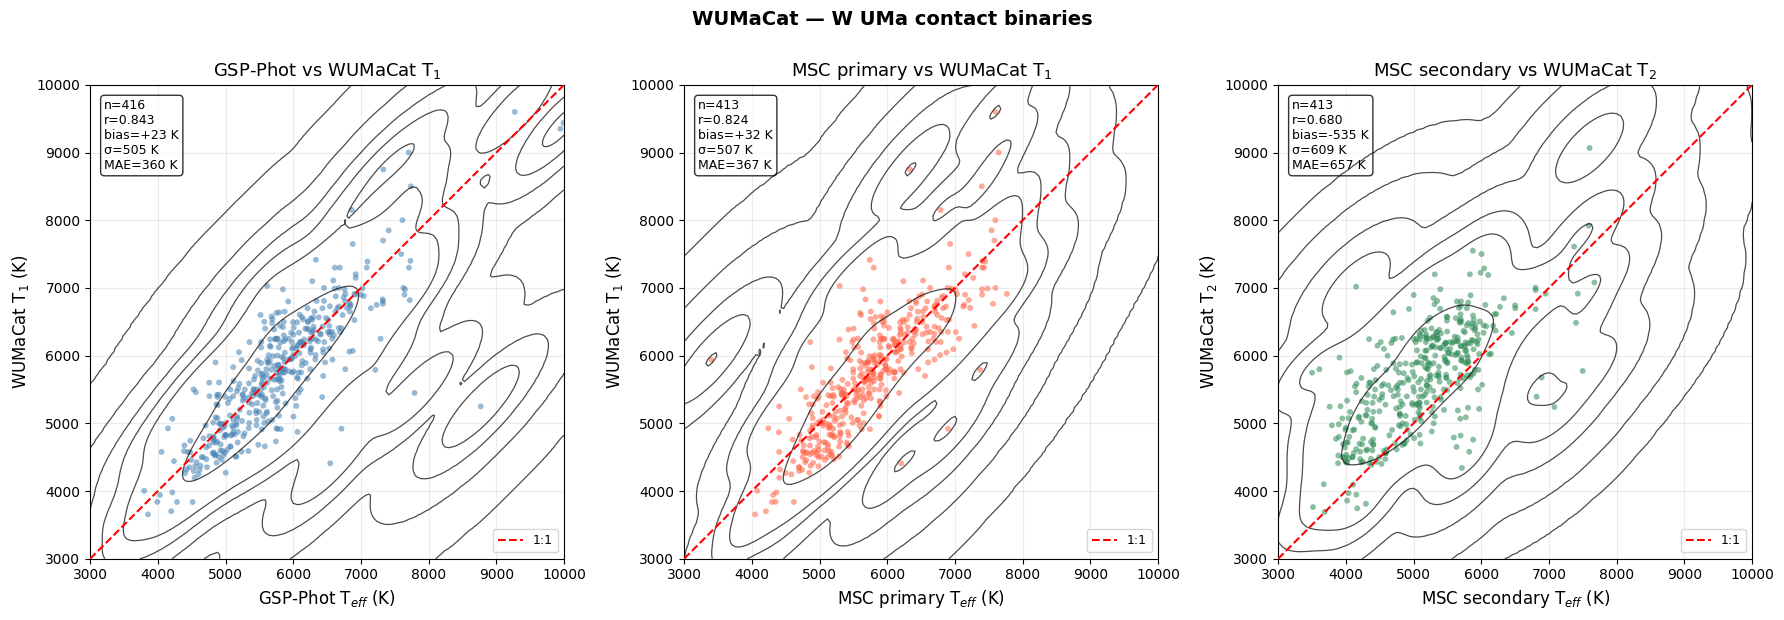

In [13]:
wuma_np = wuma.to_pandas()
LIMS_WUMA = (3000, 10000)  # WUMaCat is F–K cool stars only

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('WUMaCat — W UMa contact binaries', fontsize=14, fontweight='bold', y=1.01)

scatter_kde_panel(
    axes[0],
    x=wuma_np['teff_gaia_corrected'].values,
    y=wuma_np['T1_cat'].values,
    xlabel='GSP-Phot T$_{eff}$ (K)',
    ylabel='WUMaCat T$_1$ (K)',
    title='GSP-Phot vs WUMaCat T$_1$',
    lims=LIMS_WUMA, color='steelblue',
)
scatter_kde_panel(
    axes[1],
    x=wuma_np['teff_msc1'].replace(-999.0, float('nan')).values,
    y=wuma_np['T1_cat'].values,
    xlabel='MSC primary T$_{eff}$ (K)',
    ylabel='WUMaCat T$_1$ (K)',
    title='MSC primary vs WUMaCat T$_1$',
    lims=LIMS_WUMA, color='tomato',
)
scatter_kde_panel(
    axes[2],
    x=wuma_np['teff_msc2'].replace(-999.0, float('nan')).values,
    y=wuma_np['T2_cat'].values,
    xlabel='MSC secondary T$_{eff}$ (K)',
    ylabel='WUMaCat T$_2$ (K)',
    title='MSC secondary vs WUMaCat T$_2$',
    lims=LIMS_WUMA, color='seagreen',
)

plt.tight_layout()
save_figure(fig, 'wumacat_teff_comparison.png', 'spectroscopic_comparison')
plt.show()

---\n## Period–Temperature correlation\n\n**Physical expectation:** longer period → larger orbital separation → room for bigger/hotter stars.\n**Question:** does this hold in DEBCat (ground truth), and does MSC (capped at 8 000 K) follow the same trend or break at long periods?

In [14]:
# ── DEBCat: prepare period + component temperatures ──────────────────────────
deb_pt = deb_raw.copy()
deb_pt['T1'] = 10 ** deb_pt['logT1'].astype(float)
deb_pt['T2'] = 10 ** deb_pt['logT2'].astype(float)
deb_pt['P']  = deb_pt['Pday'].astype(float)
deb_pt.loc[deb_pt['T1'] < 100, 'T1'] = float('nan')
deb_pt.loc[deb_pt['T2'] < 100, 'T2'] = float('nan')
deb_pt = deb_pt.dropna(subset=['P', 'T1'])

print(f"DEBCat: {len(deb_pt)} objects with P + T1")
print(f"  Period range : [{deb_pt.P.min():.2f}, {deb_pt.P.max():.2f}] days")
print(f"  T1 range     : [{deb_pt.T1.min():.0f}, {deb_pt.T1.max():.0f}] K")

r1, p1 = stats.spearmanr(np.log10(deb_pt['P']), deb_pt['T1'])
r2, p2 = stats.spearmanr(np.log10(deb_pt.dropna(subset=['T2'])['P']),
                          deb_pt.dropna(subset=['T2'])['T2'])
print(f"\n  Spearman ρ(log P, T1) = {r1:+.3f}  p={p1:.1e}")
print(f"  Spearman ρ(log P, T2) = {r2:+.3f}  p={p2:.1e}")

# ── Load Gaia EB periods for full MSC sample ──────────────────────────────────
add_params = Table.read(
    'data/raw/eb_additional_params-result.ecsv', format='ascii.ecsv'
).to_pandas()[['source_id', 'frequency']]
add_params['period_days'] = 1.0 / add_params['frequency'].astype(float)

# Join periods into the unified catalog, keep only MSC objects
msc_full = (
    pl.read_parquet(config.get_dataset_path('eb_catalog_teff', 'processed'))
    .select(['source_id', 'teff_gaia_corrected', 'teff_msc1', 'teff_msc2'])
    .filter(has('teff_msc1'))
    .join(pl.from_pandas(add_params), on='source_id', how='left')
    .to_pandas()
)
msc_full['teff_msc1'] = msc_full['teff_msc1'].replace(-999.0, float('nan'))
msc_full['teff_msc2'] = msc_full['teff_msc2'].replace(-999.0, float('nan'))
msc_full['teff_gaia_corrected'] = msc_full['teff_gaia_corrected'].replace(-999.0, float('nan'))

msc_pt = msc_full.dropna(subset=['period_days', 'teff_msc1'])
print(f"\nMSC full sample: {len(msc_pt):,} objects with period + teff_msc1")
print(f"  Period range : [{msc_pt.period_days.min():.2f}, {msc_pt.period_days.max():.2f}] days")
print(f"  Teff_msc1 range: [{msc_pt.teff_msc1.min():.0f}, {msc_pt.teff_msc1.max():.0f}] K")

r3, p3 = stats.spearmanr(np.log10(msc_pt['period_days']), msc_pt['teff_msc1'])
print(f"\n  Spearman ρ(log P, teff_msc1) = {r3:+.3f}  p={p3:.1e}")

DEBCat: 311 objects with P + T1
  Period range : [0.45, 987.40] days
  T1 range     : [2992, 38019] K

  Spearman ρ(log P, T1) = -0.351  p=1.8e-10
  Spearman ρ(log P, T2) = -0.254  p=6.2e-06



MSC full sample: 1,074,092 objects with period + teff_msc1
  Period range : [0.20, 643.26] days
  Teff_msc1 range: [3005, 7997] K



  Spearman ρ(log P, teff_msc1) = +0.018  p=6.3e-79


### Figure 8 — DEBCat: period vs component temperatures (ground truth)

   Saved: reports/figures/spectroscopic_comparison/debcat_period_temperature.png


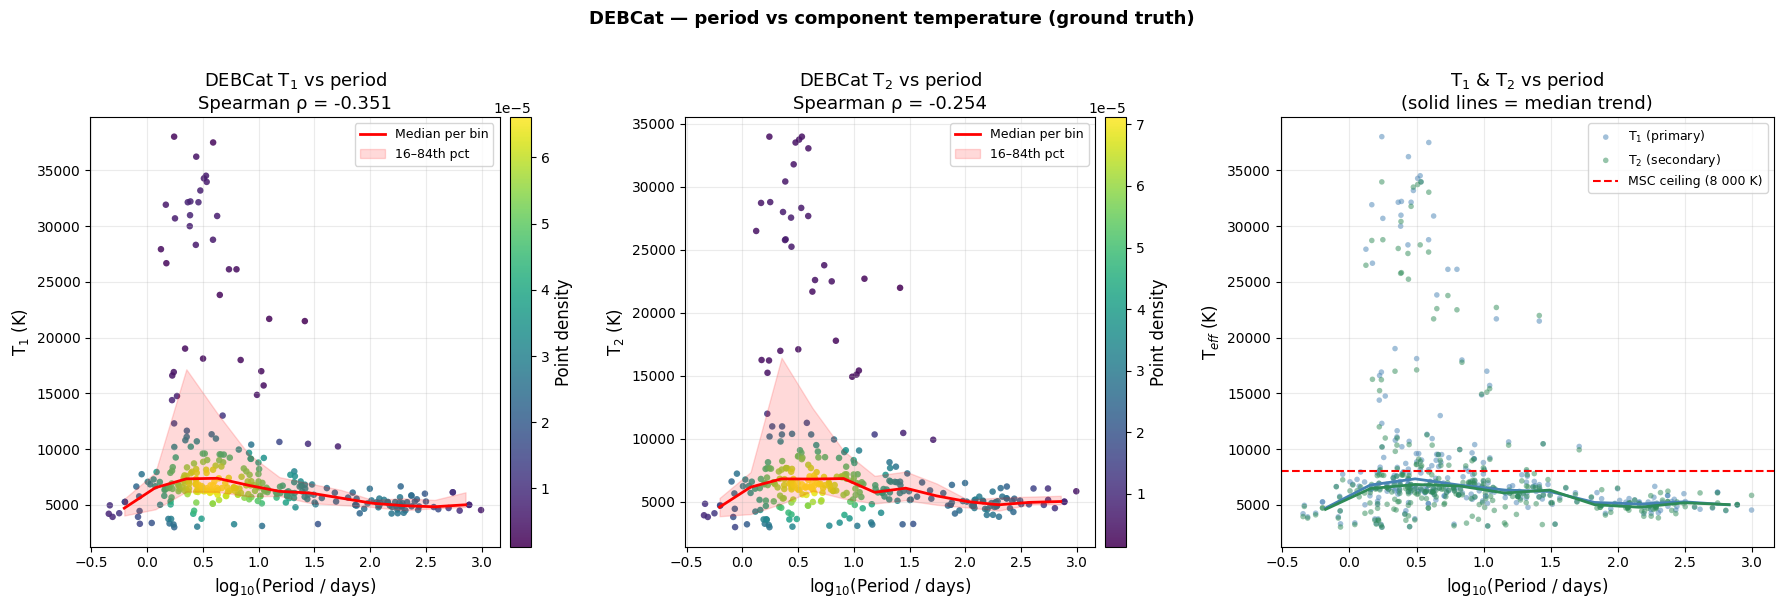

In [15]:
def binned_median(logp, teff, n_bins=10):
    """Return bin centres and median Teff per log-period bin."""
    bins = np.linspace(logp.min(), logp.max(), n_bins + 1)
    centres, medians, p16s, p84s = [], [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (logp >= lo) & (logp < hi)
        if mask.sum() >= 3:
            centres.append((lo + hi) / 2)
            medians.append(np.median(teff[mask]))
            p16s.append(np.percentile(teff[mask], 16))
            p84s.append(np.percentile(teff[mask], 84))
    return np.array(centres), np.array(medians), np.array(p16s), np.array(p84s)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('DEBCat — period vs component temperature (ground truth)', fontsize=13, fontweight='bold', y=1.01)

logP_deb = np.log10(deb_pt['P'].values)

panels_deb = [
    (deb_pt['T1'].values,                             'T$_1$ (K)',       'steelblue', 'DEBCat T$_1$ vs period'),
    (deb_pt['T2'].dropna().values,                    'T$_2$ (K)',       'seagreen',  'DEBCat T$_2$ vs period'),
    (None, None, None, None),   # placeholder for combined
]

# Panel 1: T1 vs log P (density-coloured scatter)
for ax, (teff_arr, ylabel, color, title) in zip(axes[:2], panels_deb[:2]):
    if title is None:
        continue
    logp = np.log10(deb_pt['P'].values) if ylabel == 'T$_1$ (K)' else np.log10(deb_pt.dropna(subset=['T2'])['P'].values)
    teff_valid = teff_arr[np.isfinite(teff_arr)]
    logp_valid = logp[np.isfinite(teff_arr)]

    # density colour
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(np.vstack([logp_valid, teff_valid]))
    density = kde(np.vstack([logp_valid, teff_valid]))
    order = np.argsort(density)
    sc = ax.scatter(logp_valid[order], teff_valid[order], c=density[order],
                    cmap='viridis', s=22, alpha=0.85, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='Point density', pad=0.02)

    # binned median trend
    bc, bm, bp16, bp84 = binned_median(logp_valid, teff_valid, n_bins=12)
    ax.plot(bc, bm, 'r-', lw=2, zorder=5, label='Median per bin')
    ax.fill_between(bc, bp16, bp84, color='red', alpha=0.15, label='16–84th pct')

    r, _ = stats.spearmanr(logp_valid, teff_valid)
    ax.set_xlabel('log$_{10}$(Period / days)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title}\nSpearman ρ = {r:+.3f}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

# Panel 3: T1 and T2 overlaid on the same axes
ax = axes[2]
deb_t2 = deb_pt.dropna(subset=['T2'])
ax.scatter(np.log10(deb_pt['P']), deb_pt['T1'], s=16, alpha=0.5, color='steelblue',
           edgecolors='none', label='T$_1$ (primary)')
ax.scatter(np.log10(deb_t2['P']), deb_t2['T2'], s=16, alpha=0.5, color='seagreen',
           edgecolors='none', label='T$_2$ (secondary)')

bc1, bm1, _, _ = binned_median(np.log10(deb_pt['P'].values), deb_pt['T1'].values, n_bins=10)
bc2, bm2, _, _ = binned_median(np.log10(deb_t2['P'].values), deb_t2['T2'].values, n_bins=10)
ax.plot(bc1, bm1, 'steelblue', lw=2, zorder=5)
ax.plot(bc2, bm2, 'seagreen',  lw=2, zorder=5)
ax.axhline(8000, color='red', lw=1.5, linestyle='--', label='MSC ceiling (8 000 K)')

ax.set_xlabel('log$_{10}$(Period / days)')
ax.set_ylabel('T$_{eff}$ (K)')
ax.set_title('T$_1$ & T$_2$ vs period\n(solid lines = median trend)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
save_figure(fig, 'debcat_period_temperature.png', 'spectroscopic_comparison')
plt.show()

### Figure 9 — MSC vs DEBCat: does the period–temperature trend break?

   Saved: reports/figures/spectroscopic_comparison/period_temperature_msc_vs_debcat.png


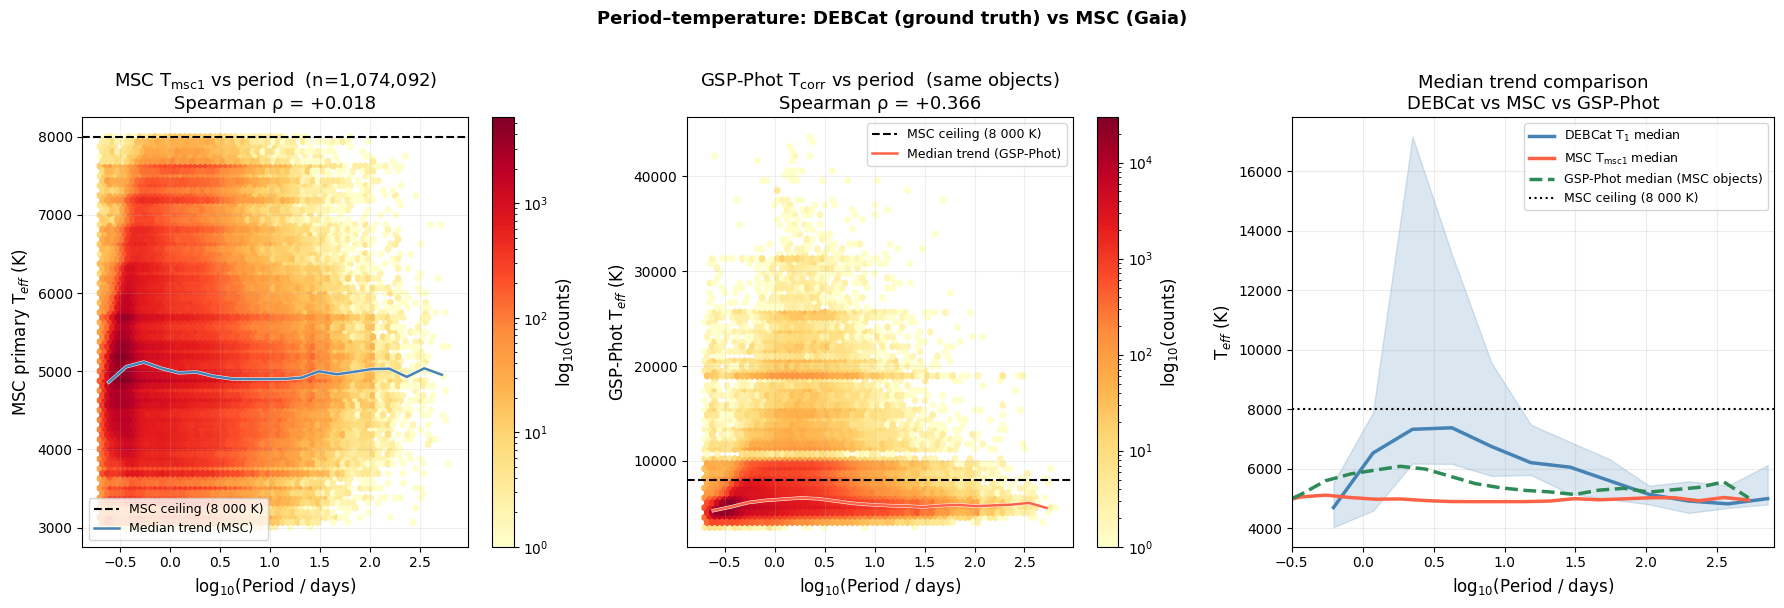

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Period–temperature: DEBCat (ground truth) vs MSC (Gaia)', fontsize=13, fontweight='bold', y=1.01)

logP_msc = np.log10(msc_pt['period_days'].values)
t_msc1   = msc_pt['teff_msc1'].values
t_gsp    = msc_pt['teff_gaia_corrected'].values
logP_deb_all = np.log10(deb_pt['P'].values)

# Panel 1: MSC primary Teff vs period (full 1M sample — hexbin for density)
ax = axes[0]
hb = ax.hexbin(logP_msc, t_msc1, gridsize=70, cmap='YlOrRd', mincnt=1, bins='log')
plt.colorbar(hb, ax=ax, label='log$_{10}$(counts)')
ax.axhline(8000, color='k', lw=1.5, linestyle='--', label='MSC ceiling (8 000 K)')
bc, bm, bp16, bp84 = binned_median(logP_msc, t_msc1, n_bins=20)
ax.plot(bc, bm, 'w-', lw=2.5, zorder=5)
ax.plot(bc, bm, 'steelblue', lw=1.8, zorder=6, label='Median trend (MSC)')
r_msc, _ = stats.spearmanr(logP_msc, t_msc1)
ax.set_xlabel('log$_{10}$(Period / days)')
ax.set_ylabel('MSC primary T$_{eff}$ (K)')
ax.set_title(f'MSC T$_{{\\rm msc1}}$ vs period  (n={len(msc_pt):,})\nSpearman ρ = {r_msc:+.3f}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# Panel 2: GSP-Phot Teff vs period for the same MSC objects
ax = axes[1]
gsp_mask = np.isfinite(t_gsp)
hb = ax.hexbin(logP_msc[gsp_mask], t_gsp[gsp_mask], gridsize=70, cmap='YlOrRd', mincnt=1, bins='log')
plt.colorbar(hb, ax=ax, label='log$_{10}$(counts)')
ax.axhline(8000, color='k', lw=1.5, linestyle='--', label='MSC ceiling (8 000 K)')
bc2, bm2, _, _ = binned_median(logP_msc[gsp_mask], t_gsp[gsp_mask], n_bins=20)
ax.plot(bc2, bm2, 'w-', lw=2.5, zorder=5)
ax.plot(bc2, bm2, 'tomato', lw=1.8, zorder=6, label='Median trend (GSP-Phot)')
r_gsp, _ = stats.spearmanr(logP_msc[gsp_mask], t_gsp[gsp_mask])
ax.set_xlabel('log$_{10}$(Period / days)')
ax.set_ylabel('GSP-Phot T$_{eff}$ (K)')
ax.set_title(f'GSP-Phot T$_{{\\rm corr}}$ vs period  (same objects)\nSpearman ρ = {r_gsp:+.3f}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# Panel 3: Median trends overlaid — DEBCat T1, MSC primary, GSP-Phot
ax = axes[2]
bc_deb, bm_deb, bp16_deb, bp84_deb = binned_median(logP_deb_all, deb_pt['T1'].values, n_bins=12)
ax.fill_between(bc_deb, bp16_deb, bp84_deb, color='steelblue', alpha=0.2)
ax.plot(bc_deb, bm_deb, 'steelblue', lw=2.5, label='DEBCat T$_1$ median')

ax.plot(bc,  bm,  color='tomato',   lw=2.5, linestyle='-',  label='MSC T$_{\\rm msc1}$ median')
ax.plot(bc2, bm2, color='seagreen', lw=2.5, linestyle='--', label='GSP-Phot median (MSC objects)')
ax.axhline(8000, color='k', lw=1.5, linestyle=':', label='MSC ceiling (8 000 K)')

ax.set_xlabel('log$_{10}$(Period / days)')
ax.set_ylabel('T$_{eff}$ (K)')
ax.set_title('Median trend comparison\nDEBCat vs MSC vs GSP-Phot')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.set_xlim(-0.5, 2.9)

plt.tight_layout()
save_figure(fig, 'period_temperature_msc_vs_debcat.png', 'spectroscopic_comparison')
plt.show()

---\n## Style comparison: scatter-only vs contour-only\n\nSame three comparisons rendered in two pure styles to judge presentability.

In [17]:
def _valid(x, y, lims):
    mask = np.isfinite(x) & np.isfinite(y) & (x >= lims[0]) & (x <= lims[1]) & (y >= lims[0]) & (y <= lims[1])
    return x[mask], y[mask]

def _stats_box(ax, xv, yv):
    r, _ = stats.pearsonr(xv, yv)
    bias  = np.mean(xv - yv)
    sigma = np.std(xv - yv)
    mae   = np.mean(np.abs(xv - yv))
    ax.text(0.03, 0.97,
            f'n={len(xv)}\nr={r:.3f}\nbias={bias:+.0f} K\nσ={sigma:.0f} K\nMAE={mae:.0f} K',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

def _decorate(ax, lims, xlabel, ylabel, title):
    ax.plot(lims, lims, 'r--', lw=1.5, label='1:1', zorder=10)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9, loc='lower right')

# ── pure scatter ──────────────────────────────────────────────────────────────
def scatter_panel(ax, x, y, xlabel, ylabel, title, lims, color):
    xv, yv = _valid(x, y, lims)
    ax.scatter(xv, yv, s=18, alpha=0.6, color=color, edgecolors='none')
    if len(xv) >= 2:
        _stats_box(ax, xv, yv)
    _decorate(ax, lims, xlabel, ylabel, title)

# ── density-coloured scatter ──────────────────────────────────────────────────
def density_scatter_panel(ax, x, y, xlabel, ylabel, title, lims, cmap='viridis'):
    """
    Scatter plot where each point is coloured by its local point density
    estimated via KDE evaluated at the point positions.
    Dense regions → bright; sparse regions → dark.
    """
    from scipy.stats import gaussian_kde

    xv, yv = _valid(x, y, lims)
    if len(xv) < 2:
        _decorate(ax, lims, xlabel, ylabel, title)
        return

    # Evaluate KDE at every point location
    kde = gaussian_kde(np.vstack([xv, yv]))
    density = kde(np.vstack([xv, yv]))

    # Plot low-density points first so dense points sit on top
    order = np.argsort(density)
    sc = ax.scatter(xv[order], yv[order], c=density[order],
                    cmap=cmap, s=22, alpha=0.85, edgecolors='none', zorder=3)
    plt.colorbar(sc, ax=ax, label='Point density', pad=0.02)

    _stats_box(ax, xv, yv)
    _decorate(ax, lims, xlabel, ylabel, title)

### Scatter-only

   Saved: reports/figures/spectroscopic_comparison/debcat_scatter_only.png


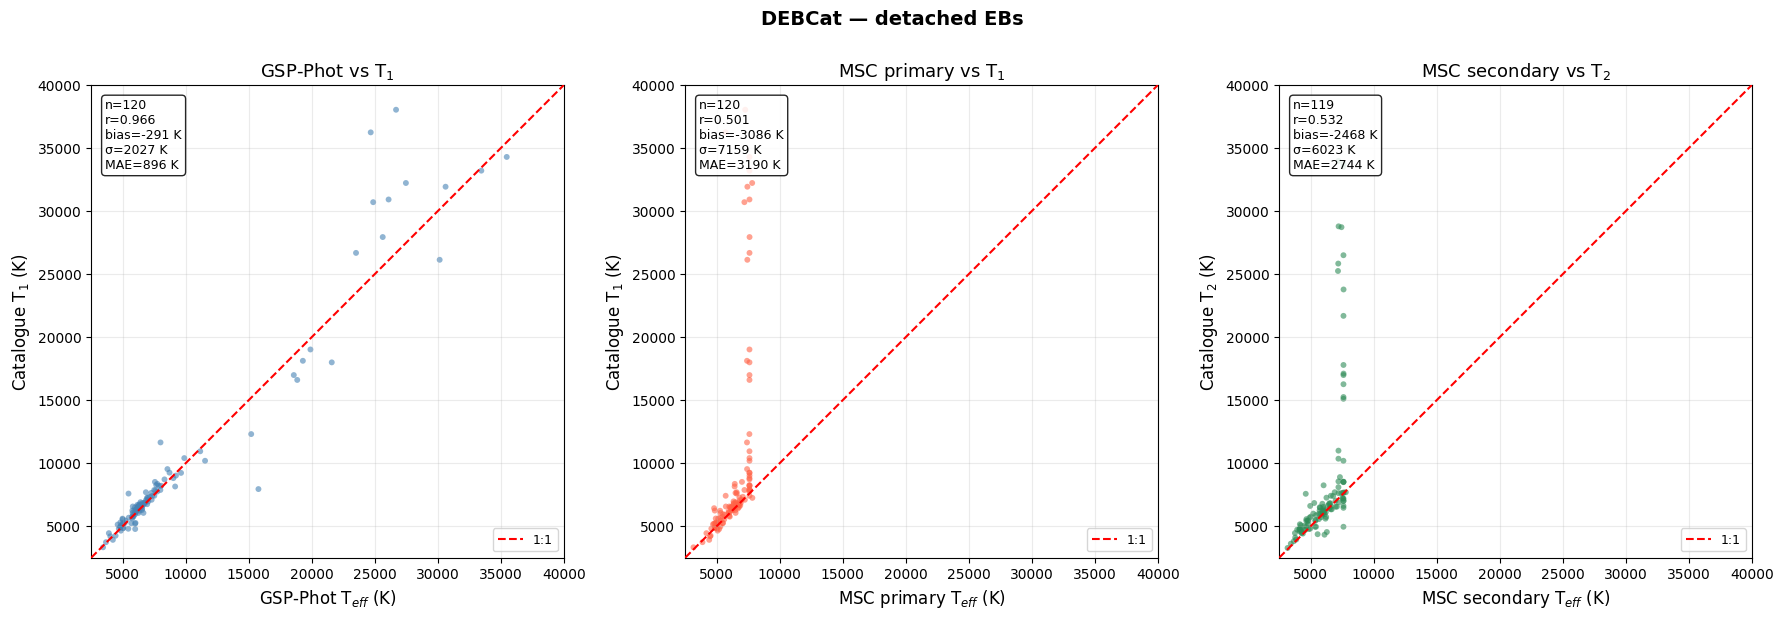

   Saved: reports/figures/spectroscopic_comparison/wumacat_scatter_only.png


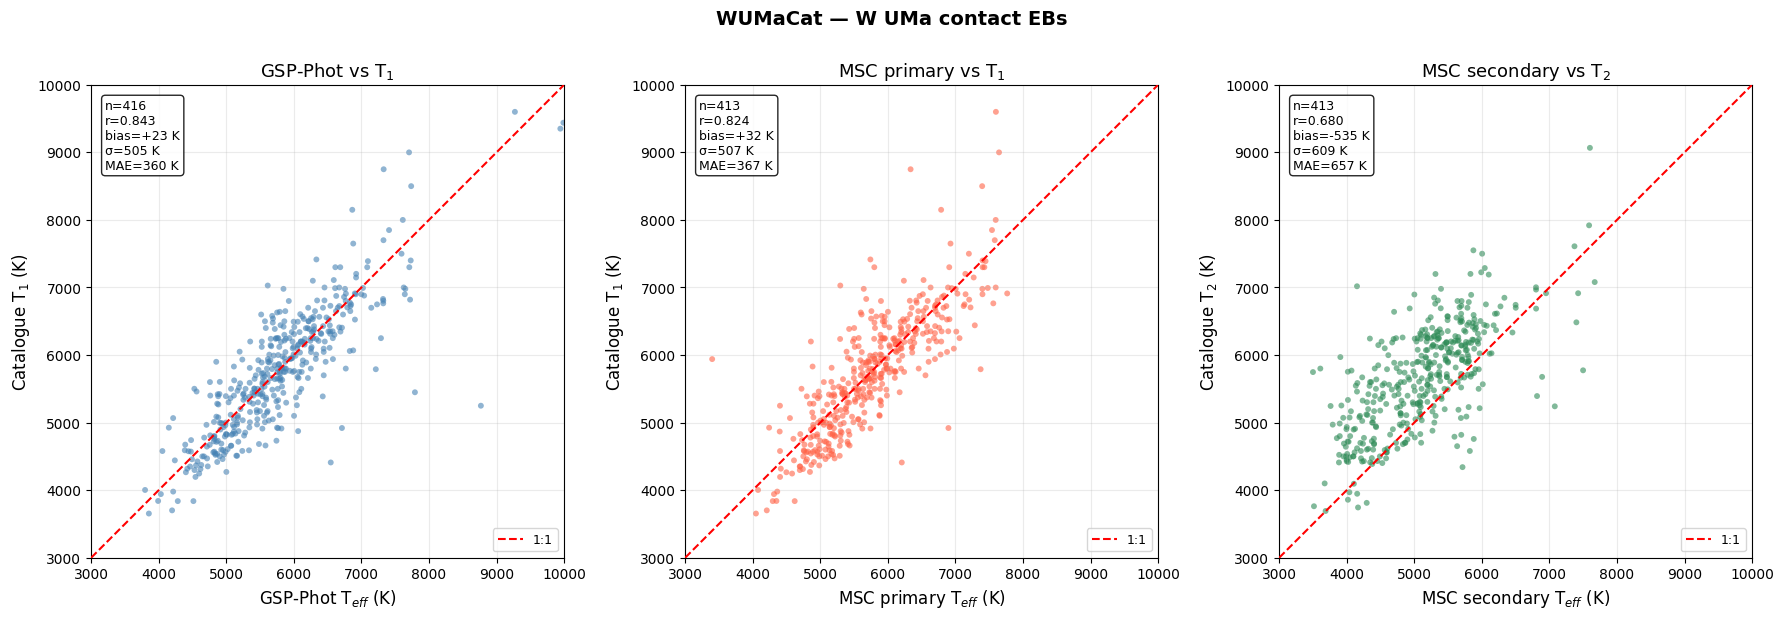

In [18]:
panels = [
    # (df_np, lims, title, fname)
    (deb_np,  LIMS_DEB,  'DEBCat — detached EBs',        'debcat_scatter_only.png'),
    (wuma_np, LIMS_WUMA, 'WUMaCat — W UMa contact EBs',  'wumacat_scatter_only.png'),
]

for df_np, lims, suptitle, fname in panels:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=1.01)

    msc1 = df_np['teff_msc1'].replace(-999.0, float('nan')).values
    msc2 = df_np['teff_msc2'].replace(-999.0, float('nan')).values

    scatter_panel(axes[0], df_np['teff_gaia_corrected'].values, df_np['T1_cat'].values,
                  'GSP-Phot T$_{eff}$ (K)', 'Catalogue T$_1$ (K)', 'GSP-Phot vs T$_1$',
                  lims, color='steelblue')
    scatter_panel(axes[1], msc1, df_np['T1_cat'].values,
                  'MSC primary T$_{eff}$ (K)', 'Catalogue T$_1$ (K)', 'MSC primary vs T$_1$',
                  lims, color='tomato')
    scatter_panel(axes[2], msc2, df_np['T2_cat'].values,
                  'MSC secondary T$_{eff}$ (K)', 'Catalogue T$_2$ (K)', 'MSC secondary vs T$_2$',
                  lims, color='seagreen')

    plt.tight_layout()
    save_figure(fig, fname, 'spectroscopic_comparison')
    plt.show()

### Density-coloured scatter

   Saved: reports/figures/spectroscopic_comparison/debcat_density_scatter.png


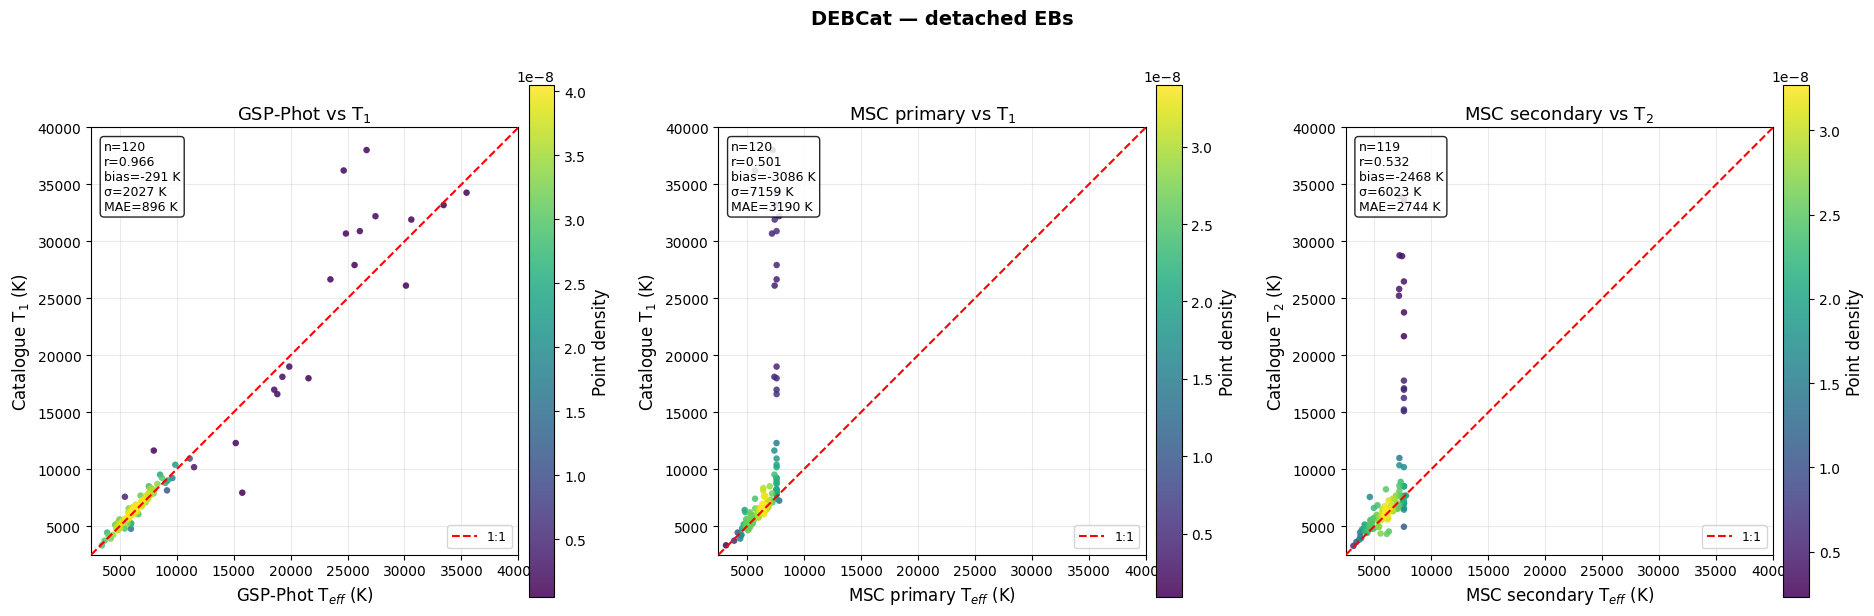

   Saved: reports/figures/spectroscopic_comparison/wumacat_density_scatter.png


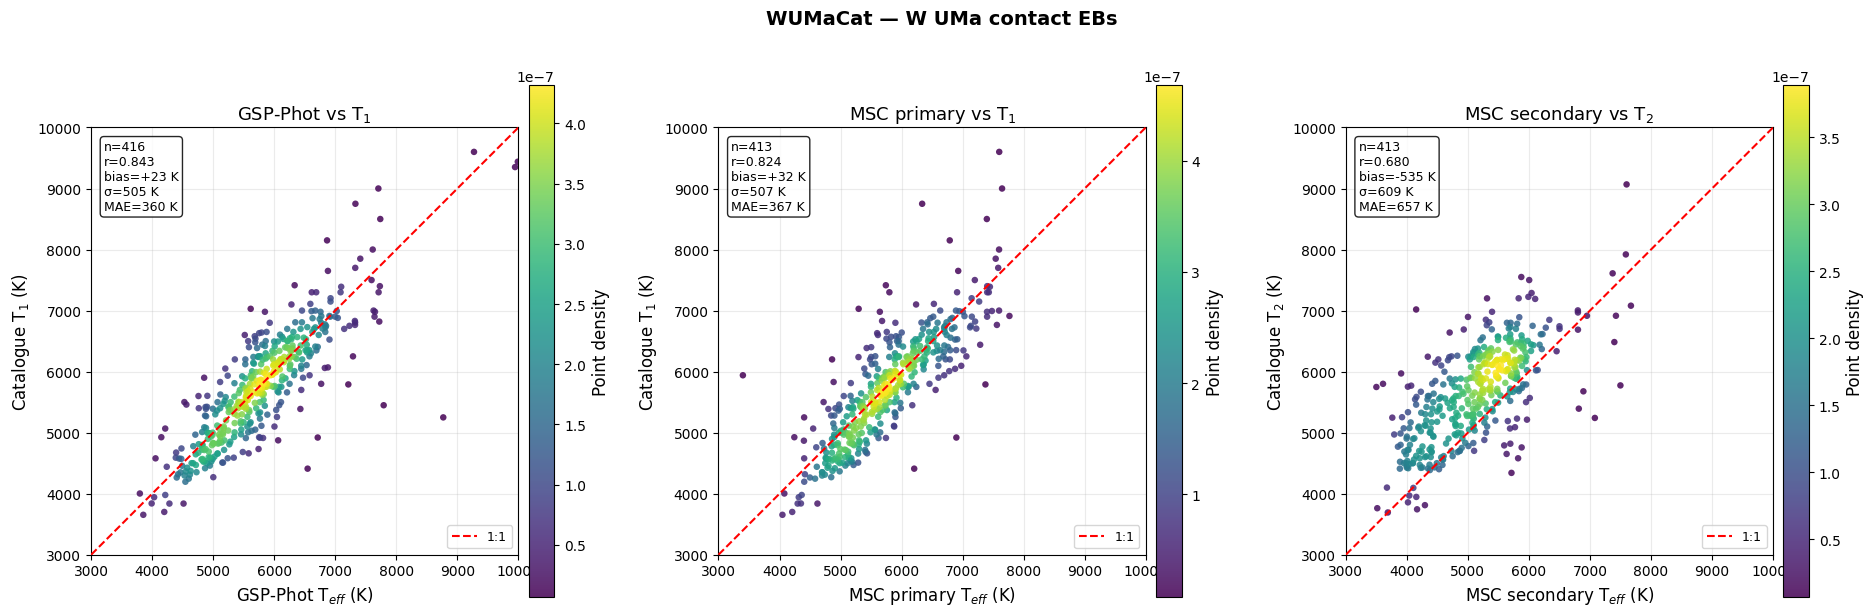

In [19]:
panels = [
    (deb_np,  LIMS_DEB,  'DEBCat — detached EBs',        'debcat_density_scatter.png'),
    (wuma_np, LIMS_WUMA, 'WUMaCat — W UMa contact EBs',  'wumacat_density_scatter.png'),
]

for df_np, lims, suptitle, fname in panels:
    fig, axes = plt.subplots(1, 3, figsize=(19, 6))
    fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=1.01)

    msc1 = df_np['teff_msc1'].replace(-999.0, float('nan')).values
    msc2 = df_np['teff_msc2'].replace(-999.0, float('nan')).values

    density_scatter_panel(axes[0], df_np['teff_gaia_corrected'].values, df_np['T1_cat'].values,
                          'GSP-Phot T$_{eff}$ (K)', 'Catalogue T$_1$ (K)', 'GSP-Phot vs T$_1$',
                          lims, cmap='viridis')
    density_scatter_panel(axes[1], msc1, df_np['T1_cat'].values,
                          'MSC primary T$_{eff}$ (K)', 'Catalogue T$_1$ (K)', 'MSC primary vs T$_1$',
                          lims, cmap='viridis')
    density_scatter_panel(axes[2], msc2, df_np['T2_cat'].values,
                          'MSC secondary T$_{eff}$ (K)', 'Catalogue T$_2$ (K)', 'MSC secondary vs T$_2$',
                          lims, cmap='viridis')

    plt.tight_layout()
    save_figure(fig, fname, 'spectroscopic_comparison')
    plt.show()